In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.stats import norm

from plot_style import set_style, C
from utils import bs_call_price, mc_iv, compute_smile
from pde_solver import (StableNormalSABRPDE, solve_pde_time_grid,
                        simulate_sabr, apply_ito_transport,
                        solve_brownian_transport_pde)

set_style()
np.set_printoptions(precision=6, suppress=True)

# Brownian Itô transport (1-D, for BM reference model)
def apply_ito_transport_bm(B_paths, dW, pde_data, sigma0):
    from scipy.interpolate import PchipInterpolator
    x_grid, f_time, fx_time = pde_data['x_grid'], pde_data['f_time'], pde_data['fx_time']
    n_paths, n_times = B_paths.shape
    X = np.zeros_like(B_paths)
    X[:, 0] = PchipInterpolator(x_grid, f_time[0], extrapolate=True)(B_paths[:, 0])
    for k in range(n_times - 1):
        fx = PchipInterpolator(x_grid, fx_time[k], extrapolate=True)(B_paths[:, k])
        X[:, k+1] = X[:, k] + sigma0 * fx * dW[:, k]
    return X

In [2]:
s0 = 100
market_p = {'alpha':10, 'rho':-0.15, 'nu':0.55, 's0':s0}
reference_p = {'alpha':10, 'rho':-0.1, 'nu':0.7, 's0':s0}
moneyness  = np.linspace(0.85, 1.15, 15)
strikes = s0 * moneyness
T, n_steps, n_paths = 1.0, 252, 200_000 

In [ ]:
# ── Hagan approximation: normal SABR analytical IV ───
def iv_hagan(strikes, s0, alpha, rho, nu, T):
    z = nu/alpha * np.sqrt(s0 * strikes) * np.log(s0 / strikes)
    x = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))
    return (alpha
        * np.divide(np.log(s0/strikes)*z, (s0 - strikes)*x,
                    where=np.abs(s0 - strikes) > 1e-12,
                    out=np.array(strikes, dtype=float))
        * (1 + T*(alpha**2/(24*s0*strikes) + (2 - 3*rho**2)/24 * nu**2)))

# ── Breeden-Litsenberger CDF from Hagan smile ───
def cdf_from_params(p, strikes):
    vals = np.diff(bs_call_price(p["s0"], iv_hagan(strikes, p["s0"], p["alpha"], p["rho"], p["nu"], T), T, strikes)) / dx + 1
    return vals

# ── BS implied-vol smile from MC terminal samples ───
def compute_smile_from_samples(terminal_samples, strikes, T):
    F    = np.mean(terminal_samples)
    vols = mc_iv(F, T, strikes, terminal_samples)
    return {"strikes": strikes, "vols": vols, "F": F}

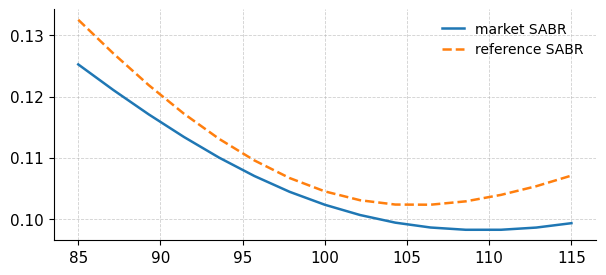

In [ ]:
Y_market, _, _, _ = simulate_sabr(s0, market_p['alpha'], market_p['nu'], market_p['rho'], T, n_paths, n_steps)
Y_ref, _, _, _    = simulate_sabr(s0, reference_p['alpha'], reference_p['nu'], reference_p['rho'], T, n_paths, n_steps)

iv_market = mc_iv(s0, T, strikes, Y_market[:, -1])
iv_ref    = mc_iv(s0, T, strikes, Y_ref[:, -1])

plt.figure(figsize=(7, 3))
plt.plot(strikes, iv_market, "-",  label="market SABR")
plt.plot(strikes, iv_ref,    "--", label="reference SABR")
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

In [5]:
# Compute the breniar map between sabrs
N, nsigma = 500, 40
strikes = np.linspace(-nsigma, nsigma, 2 * N + 3) + s0 + 1e-6
dx = strikes[1] - strikes[0]

ref_cdf_vals    = cdf_from_params(reference_p, strikes)
market_cdf_vals = cdf_from_params(market_p, strikes)

ref_cdf    = interp1d(strikes[1:], ref_cdf_vals,    kind="linear", bounds_error=False, fill_value=(0, 1))
market_cdf = interp1d(strikes[1:], market_cdf_vals, kind="linear", bounds_error=False, fill_value=(0, 1))
market_qf  = interp1d(market_cdf_vals, strikes[1:], kind="linear", bounds_error=False, fill_value=(strikes[0], strikes[-1]))

# Compute the brenier map from sabr and sabr
brenier_map_1 = lambda x: market_qf(ref_cdf(x))

# compute the brenier map from broanian to sabr 
brenier_map_2 = lambda x: market_qf(norm.cdf(x))

In [6]:
y0 = reference_p['s0']

delta_y  = 3
y_down   = y0 - delta_y
y_mid    = y0
y_up     = y0 + delta_y

Ny, Nu, n_steps = 181, 111, 250
strikes_plot = np.linspace(y_down - 3*reference_p['alpha'], y_up + 3*reference_p['alpha'], 55)

g0_sabr = brenier_map_1
g0_bm   = lambda x: market_qf(norm.cdf((x - y0) / (reference_p['alpha'] * np.sqrt(T))))

_Y_mkt, _, _, _ = simulate_sabr(y0, market_p['alpha'], market_p['nu'], market_p['rho'],
                                 T, n_paths, n_steps)
target_smile_0 = compute_smile_from_samples(_Y_mkt[:, -1], strikes_plot, T)

In [ ]:
shifts = {"down": -delta_y, "mid": 0.0, "up": +delta_y}

# ── SABR reference ───
Y, A, dW_s, dZ_s = simulate_sabr(
    y0=y0, alpha=reference_p['alpha'], nu=reference_p['nu'], rho=reference_p['rho'],
    T=T, n_paths=n_paths, n_steps=n_steps, seed=42)

print("Solving SABR transport PDE…")

sabr_pde = solve_pde_time_grid(StableNormalSABRPDE(nu=reference_p['nu'], rho=reference_p['rho'], T=T,
                        Ny=Ny, Nu=Nu, Nt=n_steps, y_width=10.0, u_width=5.5), g0=g0_sabr, y0=y0, alpha=reference_p['alpha'])
    
tsabr = {k: compute_smile(
    apply_ito_transport(Y + dY, A, dW_s, dZ_s, sabr_pde, reference_p['nu'])[:, -1],
    strikes_plot, T) for k, dY in shifts.items()}

# ── Brownian reference ───
rng_bm = np.random.default_rng(43)
dW_b   = rng_bm.standard_normal((n_paths, n_steps)) * np.sqrt(T / n_steps)
B      = np.empty((n_paths, n_steps + 1));  B[:, 0] = y0
B[:, 1:] = y0 + np.cumsum(reference_p['alpha'] * dW_b, axis=1)
print("\nSolving Brownian transport PDE…")
bm_pde = solve_brownian_transport_pde(
    g0=g0_bm, x0=y0, sigma0=reference_p['alpha'], T=T, Nx=501, Nt=n_steps, x_width=7.0)
tbm = {k: compute_smile(
    apply_ito_transport_bm(B + dY, dW_b, bm_pde, sigma0=reference_p['alpha'])[:, -1],
    strikes_plot, T) for k, dY in shifts.items()}

Solving SABR transport PDE…
Solving PDE: Ny=181, Nu=111, Nt=250
  y ∈ [0.000, 200.000]
  α ∈ [0.2128, 469.9306]
  step 50/250
  step 100/250
  step 150/250
  step 200/250
  step 250/250

Solving Brownian transport PDE…
Solving Brownian transport PDE: Nx=501, Nt=250
  x ∈ [30.000, 170.000]


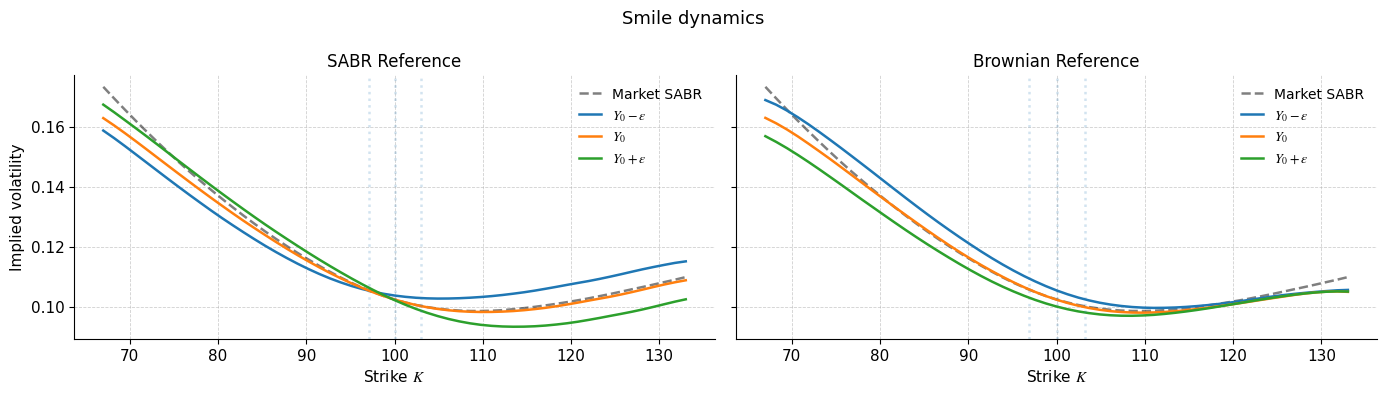

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=100, sharey=True)

labels = {"down": r"$Y_0 - \varepsilon$", "mid": r"$Y_0$", "up": r"$Y_0 + \varepsilon$"}
panels = [("SABR Reference", tsabr), ("Brownian Reference", tbm)]

for ax, (title, results) in zip(axes, panels):
    ax.plot(target_smile_0["strikes"], target_smile_0["vols"], "--",
            color="k", alpha=0.5, label="Market SABR")
    for name, res in results.items():
        ax.plot(res["strikes"], res["vols"], label=labels[name])
        ax.axvline(res["F"], linestyle=":", alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel("Strike $K$")
    ax.grid(False)
    ax.legend()

axes[0].set_ylabel("Implied volatility")
axes[0].grid(True, alpha=0.6)
axes[1].grid(True, alpha=0.6)
plt.suptitle("Smile dynamics", fontsize=13)
plt.tight_layout()
plt.show()